# FunSearch Solution Player

Interactive visualization of how CVRP solutions evolve across FunSearch milestones.

**Usage:**
1. Set `INSTANCE_NAME` and `SPEC` in the config cell below
2. Run all cells (Cell → Run All)
3. Use the slider or play button to step through milestones

## Configuration

In [1]:
# ---------- CONFIGURE THESE ----------
INSTANCE_NAME = "A-n32-k5"      # instance to visualize
SPEC = "savings"                # "savings" or "priority"
# -------------------------------------

import sys
from pathlib import Path

# Notebook lives in notebooks/ — project root is one level up
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))          # for specifications/ module
sys.path.insert(0, str(PROJECT_ROOT / "src"))  # for funsearch_cvrp package

EXPERIMENT_DIR = PROJECT_ROOT / "outputs" / "latest" / "run_funsearch"
DATASET_FOLDER = PROJECT_ROOT / "data" / "cvrplib" / "A"

print(f"Project root: {PROJECT_ROOT}")
print(f"Experiment:   {EXPERIMENT_DIR}")
print(f"Instance:     {INSTANCE_NAME}")
print(f"Spec:         {SPEC}")

Project root: /Users/laiyk/Dev/Funsearch-CVRP
Experiment:   /Users/laiyk/Dev/Funsearch-CVRP/outputs/latest/run_funsearch
Instance:     A-n32-k5
Spec:         savings


## Imports

In [2]:
import json
import math
import random
from dataclasses import asdict
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
from ipywidgets import Button, HBox, IntSlider, Label, Output, Play, VBox, jslink

from funsearch_cvrp.cvrp.core import (
    CVRPInstance,
    Solution,
    gap_score,
    is_valid_solution,
    make_greedy_solver,
    make_savings_solver,
    solution_distance,
)
from funsearch_cvrp.cvrp.io import load_cvrplib_instance, load_cvrplib_solution
from funsearch_cvrp.funsearch import code_manipulation

# Use inline backend for Jupyter
%matplotlib inline

## Load Instance & Optimal Solution

In [3]:
def load_instance(name: str, folder: Path) -> tuple[CVRPInstance, Solution | None, float | None]:
    """Load a CVRP instance and its optimal solution if available."""
    vrp_file = folder / f"{name}.vrp"
    sol_file = folder / f"{name}.sol"
    
    instance = load_cvrplib_instance(vrp_file)
    optimal_sol = None
    optimal_cost = None
    
    if sol_file.exists():
        optimal_sol, optimal_cost = load_cvrplib_solution(sol_file)
    
    return instance, optimal_sol, optimal_cost


instance, optimal_sol, optimal_cost = load_instance(INSTANCE_NAME, DATASET_FOLDER)

print(f"Loaded: {instance.name}")
print(f"  Customers: {instance.n_customers}")
print(f"  Capacity:  {instance.capacity}")
print(f"  Optimal:   {optimal_cost}")

# Pre-compute optimal distance for gap calculation
if optimal_cost:
    optimal_distance = optimal_cost
else:
    optimal_distance = solution_distance(instance, optimal_sol) if optimal_sol else None

Loaded: A-n32-k5
  Customers: 31
  Capacity:  100
  Optimal:   784.0


## Load Template Function

In [4]:
import inspect

# Import the spec module
if SPEC == "savings":
    from specifications import cvrp_spec_savings as spec_module
    function_to_evolve = "savings"
    make_solver = make_savings_solver
else:
    from specifications import cvrp_spec as spec_module
    function_to_evolve = "priority"
    make_solver = make_greedy_solver

source = inspect.getsource(getattr(spec_module, function_to_evolve))
template = code_manipulation.text_to_program(source)
template_fn = template.get_function(function_to_evolve)

print(f"Template function: {template_fn.name}")
print(f"  Args: {template_fn.args}")
print(f"  Return: {template_fn.return_type}")
print(f"  Docstring: {template_fn.docstring[:60] if template_fn.docstring else 'None'}...")

Template function: savings
  Args: i: int, j: int, instance
  Return: float
  Docstring: Score the benefit of merging a route ending at `i` with one ...


## Load & Reconstruct Milestone Programs

In [5]:
def reconstruct_function(body: str) -> str:
    """Reconstruct a full executable function from template + eval body."""
    fn = code_manipulation.Function(
        name=function_to_evolve,
        args=template_fn.args,
        body=body,
        return_type=template_fn.return_type,
        docstring=template_fn.docstring,
    )
    return str(fn).strip()


def load_milestones(exp_dir: Path) -> list[dict]:
    """Load all milestone records from eval.jsonl."""
    eval_path = exp_dir / "eval" / "eval.jsonl"
    if not eval_path.exists():
        raise FileNotFoundError(f"No eval.jsonl found at {eval_path}")
    
    milestones = []
    with open(eval_path) as f:
        for line in f:
            record = json.loads(line)
            if record.get("is_milestone") and record.get("accepted"):
                milestones.append(record)
    
    # Also include the seed (first accepted record with iteration=0 or no iteration)
    all_accepted = []
    with open(eval_path) as f:
        for line in f:
            record = json.loads(line)
            if record.get("accepted"):
                all_accepted.append(record)
    
    if all_accepted and (not milestones or all_accepted[0].get("iteration", 0) <= milestones[0].get("iteration", 0)):
        # Prepend seed if not already included
        seed = all_accepted[0]
        if not seed.get("is_milestone"):
            seed = dict(seed)
            seed["is_milestone"] = True
            seed["iteration"] = seed.get("iteration", 0)
            milestones.insert(0, seed)
    
    return milestones


milestones = load_milestones(EXPERIMENT_DIR)
print(f"Found {len(milestones)} milestone(s)")
for m in milestones:
    it = m.get("iteration", "?")
    scores = m.get("scores_per_test", {})
    # Use the last test score (hardest) as the representative score
    last_key = sorted(scores.keys(), key=int)[-1] if scores else None
    score = scores[last_key] if last_key else None
    score_str = f"{score:.4f}" if score is not None else "N/A"
    print(f"  Iter {it}: score={score_str}")

Found 2 milestone(s)
  Iter 0: score=-0.0466
  Iter 95: score=-0.0382


## Generate Solutions for Each Milestone

In [6]:
def run_program(body: str, instance: CVRPInstance) -> tuple[Solution, float, bool, str]:
    """Execute a program body and return the solution."""
    code = reconstruct_function(body)
    
    namespace = {}
    try:
        exec(code, namespace)
    except Exception as e:
        return [], 0.0, False, f"Exec error: {e}"
    
    if function_to_evolve not in namespace:
        return [], 0.0, False, "Function not found"
    
    func = namespace[function_to_evolve]
    solver = make_solver(func)
    
    try:
        solution = solver(instance)
    except Exception as e:
        return [], 0.0, False, f"Solver error: {e}"
    
    valid, reason = is_valid_solution(instance, solution)
    if not valid:
        return solution, 0.0, False, reason
    
    dist = solution_distance(instance, solution)
    return solution, dist, True, ""


# Generate solutions for all milestones
milestone_solutions = []

print("Generating solutions...")
for i, m in enumerate(milestones):
    it = m.get("iteration", i)
    sol, dist, valid, reason = run_program(m["body"], instance)
    
    gap = gap_score(dist, optimal_distance) * 100 if optimal_distance else None
    
    milestone_solutions.append({
        "iteration": it,
        "solution": sol,
        "distance": dist,
        "valid": valid,
        "reason": reason,
        "gap_pct": gap,
        "num_routes": len(sol),
    })
    
    status = "OK" if valid else f"INVALID ({reason})"
    print(f"  Milestone {it}: distance={dist:.1f}, gap={gap:.2f}% if gap else 'N/A', routes={len(sol)}, {status}")

print(f"\nDone! Generated {len(milestone_solutions)} solutions.")

Generating solutions...
  Milestone 0: distance=831.0, gap=5.99% if gap else 'N/A', routes=5, OK
  Milestone 95: distance=851.0, gap=8.55% if gap else 'N/A', routes=5, OK

Done! Generated 2 solutions.


## Visualization Function

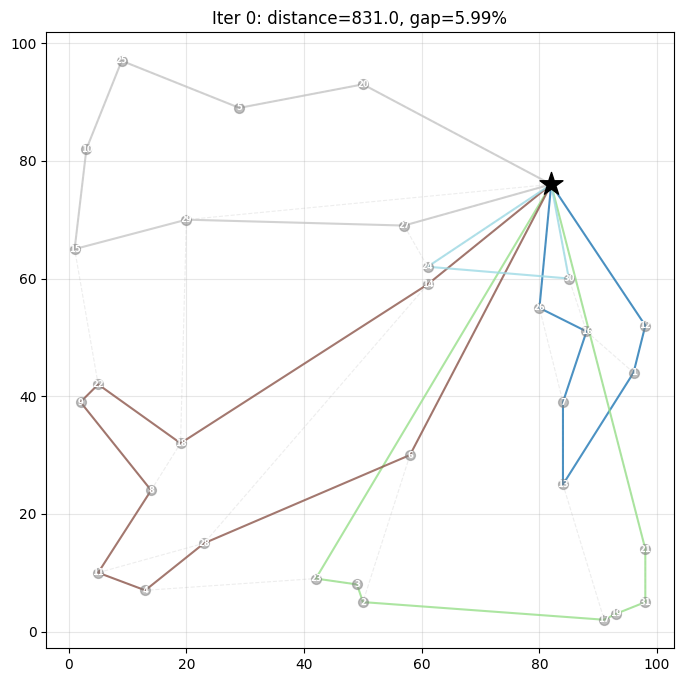

In [7]:
def draw_solution(
    instance: CVRPInstance,
    solution: Solution,
    title: str = "",
    optimal_solution: Solution | None = None,
    figsize: tuple = (10, 8),
) -> plt.Figure:
    """Draw a CVRP solution with routes."""
    fig, ax = plt.subplots(figsize=figsize)
    
    coords = instance.coords
    depot = coords[0]
    
    # Draw depot
    ax.scatter(depot[0], depot[1], s=300, c="black", marker="*", zorder=5, label="Depot")
    
    # Draw customers
    xs = [coords[i][0] for i in range(1, len(coords))]
    ys = [coords[i][1] for i in range(1, len(coords))]
    ax.scatter(xs, ys, s=50, c="gray", alpha=0.5, zorder=3)
    
    # Draw routes with distinct colors
    cmap = plt.get_cmap("tab20", max(len(solution), 1))
    for ridx, route in enumerate(solution):
        if not route:
            continue
        color = cmap(ridx % 20)
        
        # Build path: depot -> route -> depot
        path_x = [depot[0]]
        path_y = [depot[1]]
        for node in route:
            path_x.append(coords[node][0])
            path_y.append(coords[node][1])
        path_x.append(depot[0])
        path_y.append(depot[1])
        
        ax.plot(path_x, path_y, color=color, linewidth=1.5, alpha=0.8, zorder=2)
        
        # Draw customer IDs
        for node in route:
            ax.text(
                coords[node][0], coords[node][1], str(node),
                fontsize=6, ha="center", va="center",
                color="white" if ridx < 10 else "black",
                fontweight="bold",
            )
    
    # Draw optimal solution lightly if provided
    if optimal_solution:
        for route in optimal_solution:
            if not route:
                continue
            path_x = [depot[0]]
            path_y = [depot[1]]
            for node in route:
                path_x.append(coords[node][0])
                path_y.append(coords[node][1])
            path_x.append(depot[0])
            path_y.append(depot[1])
            ax.plot(path_x, path_y, color="lightgray", linewidth=0.8, alpha=0.4, zorder=1, linestyle="--")
    
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Adjust bounds with padding
    all_x = [c[0] for c in coords]
    all_y = [c[1] for c in coords]
    padding = max(max(all_x) - min(all_x), max(all_y) - min(all_y)) * 0.05
    ax.set_xlim(min(all_x) - padding, max(all_x) + padding)
    ax.set_ylim(min(all_y) - padding, max(all_y) + padding)
    
    return fig


# Test: draw the first milestone
if milestone_solutions:
    ms = milestone_solutions[0]
    title = f"Iter {ms['iteration']}: distance={ms['distance']:.1f}, gap={ms['gap_pct']:.2f}%"
    fig = draw_solution(instance, ms["solution"], title=title, optimal_solution=optimal_sol)
    plt.show()

## Interactive Player

In [ ]:
# Create interactive widgets
slider = IntSlider(
    min=0,
    max=len(milestone_solutions) - 1,
    step=1,
    value=0,
    description="Milestone:",
    continuous_update=False,
)

play = Play(
    min=0,
    max=len(milestone_solutions) - 1,
    step=1,
    interval=1500,  # ms between frames
    description="Play",
)

# Link play and slider
jslink((play, "value"), (slider, "value"))

info_label = Label(value="")
output = Output()


def update_display(change):
    idx = slider.value
    ms = milestone_solutions[idx]
    
    info = (
        f"Iteration: {ms['iteration']} | "
        f"Distance: {ms['distance']:.1f} | "
        f"Gap: {ms['gap_pct']:.2f}% | "
        f"Routes: {ms['num_routes']} | "
        f"Valid: {'Yes' if ms['valid'] else 'NO — ' + ms['reason']}"
    )
    info_label.value = info
    
    with output:
        clear_output(wait=True)
        title = f"Milestone {idx+1}/{len(milestone_solutions)} — Iteration {ms['iteration']}"
        fig = draw_solution(
            instance,
            ms["solution"],
            title=title,
            optimal_solution=optimal_sol,
        )
        plt.show()


slider.observe(update_display, names="value")

# Layout
controls = HBox([play, slider])
display(VBox([controls, info_label, output]))

# Show initial state
update_display(None)

## Side-by-Side Comparison (Optional)

Compare two specific milestones side by side.

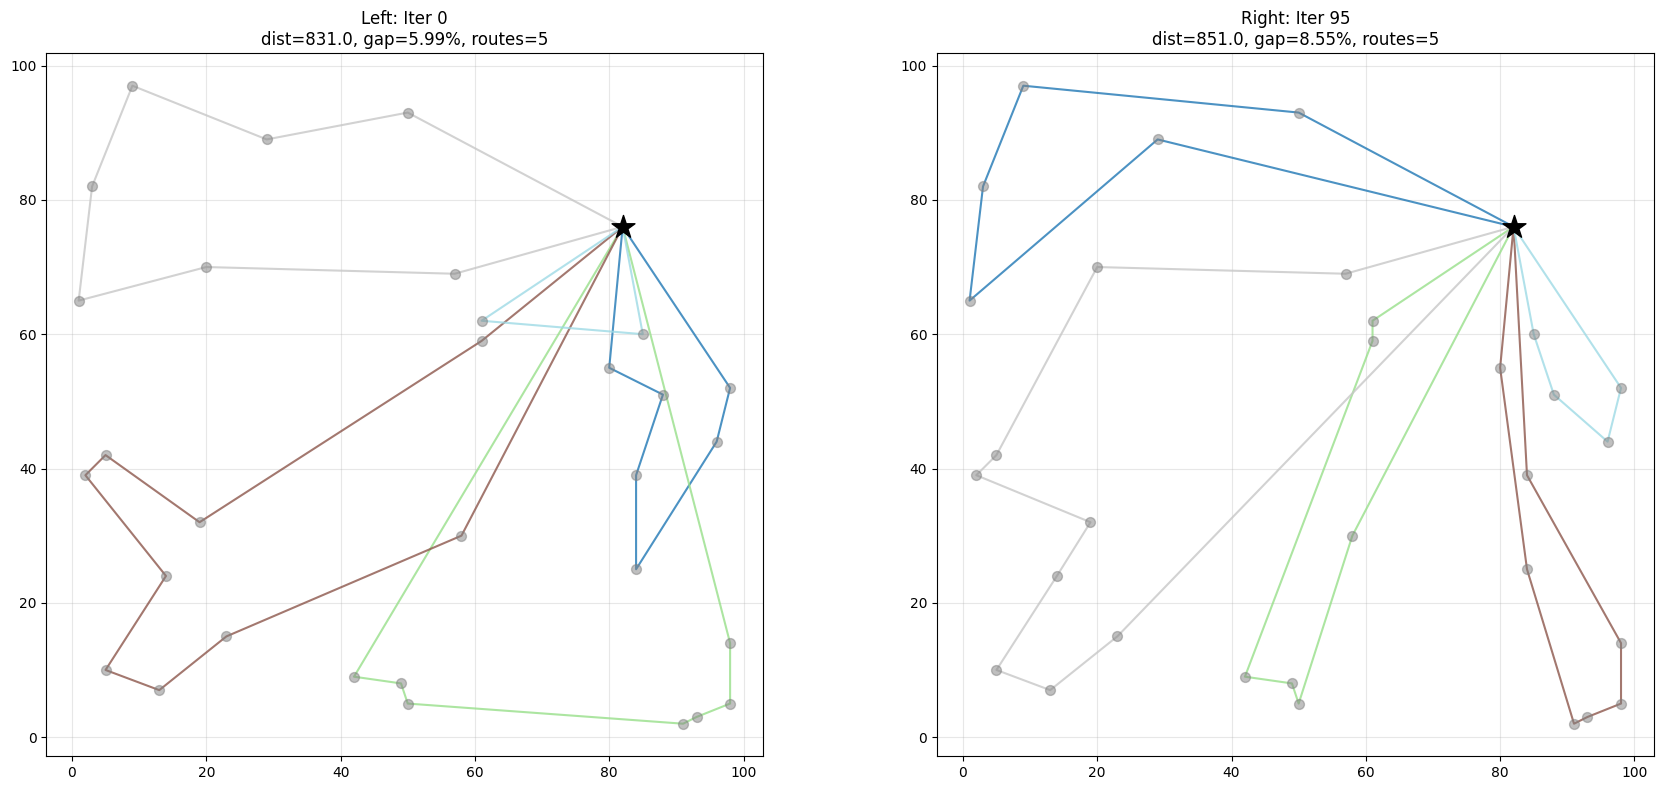

In [9]:
# Set indices to compare
LEFT_IDX = 0
RIGHT_IDX = -1 if len(milestone_solutions) > 1 else 0

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, idx, label in [(axes[0], LEFT_IDX, "Left"), (axes[1], RIGHT_IDX, "Right")]:
    ms = milestone_solutions[idx]
    coords = instance.coords
    depot = coords[0]
    
    # Depot
    ax.scatter(depot[0], depot[1], s=300, c="black", marker="*", zorder=5)
    
    # Customers
    xs = [coords[i][0] for i in range(1, len(coords))]
    ys = [coords[i][1] for i in range(1, len(coords))]
    ax.scatter(xs, ys, s=50, c="gray", alpha=0.5, zorder=3)
    
    # Routes
    cmap = plt.get_cmap("tab20", max(len(ms["solution"]), 1))
    for ridx, route in enumerate(ms["solution"]):
        if not route:
            continue
        color = cmap(ridx % 20)
        path_x = [depot[0]] + [coords[n][0] for n in route] + [depot[0]]
        path_y = [depot[1]] + [coords[n][1] for n in route] + [depot[1]]
        ax.plot(path_x, path_y, color=color, linewidth=1.5, alpha=0.8, zorder=2)
    
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(
        f"{label}: Iter {ms['iteration']}\n"
        f"dist={ms['distance']:.1f}, gap={ms['gap_pct']:.2f}%, routes={ms['num_routes']}"
    )
    
    all_x = [c[0] for c in coords]
    all_y = [c[1] for c in coords]
    padding = max(max(all_x) - min(all_x), max(all_y) - min(all_y)) * 0.05
    ax.set_xlim(min(all_x) - padding, max(all_x) + padding)
    ax.set_ylim(min(all_y) - padding, max(all_y) + padding)

plt.tight_layout()
plt.show()

## Export Animation Frames (Optional)

Save each milestone as a PNG image for creating an external animation.

In [10]:
# Uncomment to export frames
# 
# output_dir = Path("./animation_frames")
# output_dir.mkdir(exist_ok=True)
# 
# for idx, ms in enumerate(milestone_solutions):
#     title = f"{INSTANCE_NAME} — Iter {ms['iteration']}"
#     fig = draw_solution(instance, ms["solution"], title=title)
#     fig.savefig(output_dir / f"frame_{idx:03d}_iter{ms['iteration']}.png", dpi=150, bbox_inches="tight")
#     plt.close(fig)
# 
# print(f"Exported {len(milestone_solutions)} frames to {output_dir}")